Running numerical model time-stepping loop...
Simulation complete


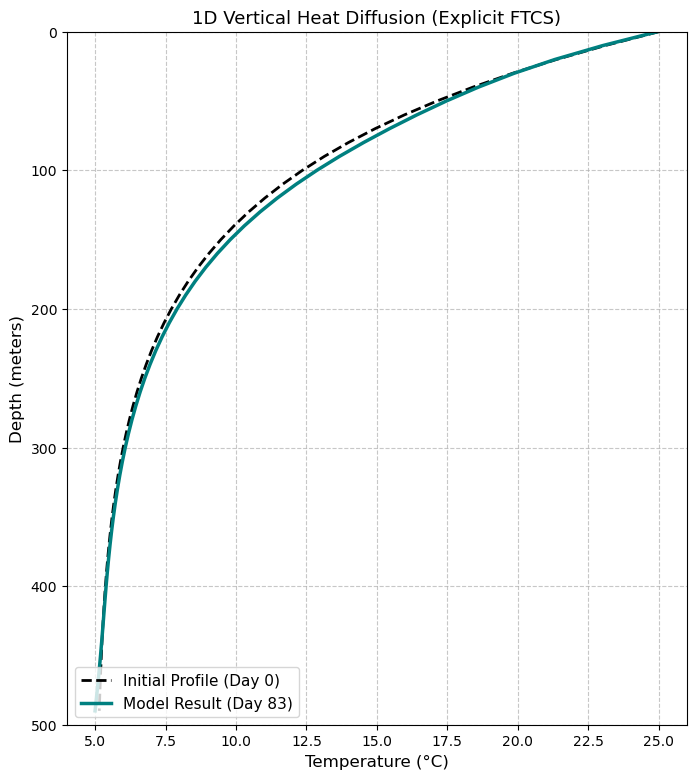

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Defining Model Grid and Constants
nz = 50                 # Number of vertical depth layers
dz = 10.0               # Thickness of each layer (meters)
depths = np.arange(nz) * dz

Nt = 2000               # Number of time steps to simulate
dt = 3600               # Size of each time step (1 hour in seconds)
K = 1e-4                # Vertical eddy diffusivity coefficient (m²/s)

# Initialize Temperature Profile (°C)
T = 5.0 + 20.0 * np.exp(-depths / 100.0)
T_initial = T.copy()

# Numerical Time-Stepping Loop (Finite Difference Method)
print("Running numerical model time-stepping loop...")
for n in range(Nt):
    T_new = T.copy()
    for k in range(1, nz - 1):
        # Heat diffusion equation discretization (second spatial derivative)
        d2T_dz2 = (T[k+1] - 2*T[k] + T[k-1]) / (dz**2)
        T_new[k] = T[k] + K * d2T_dz2 * dt
    
    # Boundary conditions: Surface forced by a seasonal sine wave cycle
    T_new[0] = 20.0 + 5.0 * np.sin(2 * np.pi * (n * dt) / (86400 * 365))
    T_new[-1] = 5.0  # Deep ocean boundary remains fixed at 5°C
    
    T = T_new

print("Simulation complete")

# Plotting the Model Results
plt.figure(figsize=(8, 9))
plt.plot(T_initial, depths, 'k--', label='Initial Profile (Day 0)', linewidth=2)
plt.plot(T, depths, 'teal', label=f'Model Result (Day {int(Nt * dt / 86400)})', linewidth=2.5)

plt.gca().invert_yaxis() 
plt.ylim(500, 0)        

plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Depth (meters)', fontsize=12)
plt.title('1D Vertical Heat Diffusion (Explicit FTCS)', fontsize=13)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)


plt.savefig("../figures/numerical_model_profile.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
yes